In [116]:
# Imports and Setup

from glass_dynamics.core.logger import logger

from glass_dynamics.data.processor import filter_and_fit_dataset
from glass_dynamics.data.composition import gen_atomic_df
from glass_dynamics.data.splitting import split_by_cassar_indices, split_by_random_seed

from glass_dynamics.features.generator import generate_all_features, generate_cassar_35_features
from glass_dynamics.features.correlation import select_features_from_clusters
from glass_dynamics.features.vif import calculate_vif, calculate_ridge_vif, iterative_vif_selection, fast_iterative_vif_selection

from glass_dynamics.analysis.performance import compute_alpha_performance_metrics
from glass_dynamics.analysis.traces import compute_weight_traces
from glass_dynamics.analysis.feature_importance import extract_importance
from glass_dynamics.analysis.evolution import extract_top_features_evolution
from glass_dynamics.analysis.extrapolation import generate_extrapolation_metrics
from glass_dynamics.analysis.myega_bootstrap import generate_bootstrap_predictions

from glass_dynamics.visualization.features_exploration_plots import plot_pearson_correlation, generate_feature_metadata_table
from glass_dynamics.visualization.performance_plots import plot_target_performance
from glass_dynamics.visualization.traces_plots import plot_normalized_traces
from glass_dynamics.visualization.importance_plots import plot_sorted_feature_importance
from glass_dynamics.visualization.evolution_plots import plot_top_features_evolution
from glass_dynamics.visualization.density_plots import plot_viscosity_density_correlation
from glass_dynamics.visualization.distance_plots import plot_rmse_vs_distance_square
from glass_dynamics.visualization.viscosity_grids import plot_viscosity_grids_bootstrap

from glass_dynamics.models.ridge import CustomRidgeRegression

from glass_dynamics.evaluation.model_evaluation import evaluate_final_model

from glass_dynamics.utils.naming import generate_glass_names

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pickle


analysis_name = "random_RMSE20"

data_path = Path(f"../../data/random_split/{analysis_name}")
plots_path = Path(f"../../plots/{analysis_name}")
model_path = Path(f"../../models/{analysis_name}")
plots_path.mkdir(parents=True, exist_ok=True)
data_path.mkdir(parents=True, exist_ok=True)
model_path.mkdir(parents=True, exist_ok=True)


In [117]:
# Data Loading
logger.info("Loading raw datasets...")

raw_data = pd.read_csv('../../data/viscosity_raw_data.csv', index_col=0) 
chemical_props_T = pd.read_csv("../../data/chemical_properties.csv", index_col=0).T
chemical_props = pd.read_csv("../../data/chemical_properties.csv", index_col=0)
# raw_data


[INFO] 2026-06-07 15:51:22 - Loading raw datasets...


In [118]:
# MYEGA Fit and Filter
clean_glasses_df, rejected_glasses_df = filter_and_fit_dataset(raw_data, min_r2_threshold=0.99, max_rmse_threshold=0.20)
y_targets = clean_glasses_df[['ID', 'Tg_fitted', 'm_fitted', 'log_eta_inf_fitted']].set_index('ID')
oxides_df = clean_glasses_df.drop(columns=['Tg_fitted', 'm_fitted', 'log_eta_inf_fitted', 'myega_r2', 'myega_rmse']).set_index('ID')
# oxides_df


[INFO] 2026-06-07 15:51:22 - Starting data processing and MYEGA fitting on 847 unique glasses...
[INFO] 2026-06-07 15:51:29 - Processing complete. Accepted glasses: 621. Rejected glasses: 226.


In [119]:
# Convert Oxides to Elements
atomic_df = gen_atomic_df(oxides_df, chemical_props_T)
# atomic_df


[INFO] 2026-06-07 15:51:29 - Converting compound fractions to elemental atomic fractions using chemparse...
[INFO] 2026-06-07 15:51:29 - Successfully converted. Output shape: (621, 59)


In [120]:
# # Generate cassar viscnet features
# X_cassar_features = generate_cassar_35_features(atomic_df, chemical_props)
# X_cassar_features

In [121]:
# This generates 560 features
X_all_features = generate_all_features(atomic_df, chemical_props)
# X_all_features


[INFO] 2026-06-07 15:51:29 - Generating all W and A features from 56 chemical properties...
[INFO] 2026-06-07 15:51:54 - Feature generation complete. Total features created: 560


In [122]:
# Data splitting
X_train, X_test, y_train, y_test = split_by_random_seed(X_all_features, y_targets, test_size=0.1)
# X_test

[INFO] 2026-06-07 15:51:55 - Splitting dataset randomly (test_size=10%, seed=42)...
[INFO] 2026-06-07 15:51:55 - Split complete. Train size: 558, Test size: 63


In [123]:
# Standardize features and output
X_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = StandardScaler().set_output(transform="pandas")
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# y_test_scaled

In [124]:
# Safety step: removing features with a low standard deviation less than 10^-3
train_std = X_train_scaled.std()
features_with_std = train_std[train_std > 1e-3].index.tolist()
X_filtered = X_train_scaled[features_with_std]

logger.info(f"Features remaining after standard deviation filter (> 10^-3): {X_filtered.shape[1]}")

[INFO] 2026-06-07 15:51:55 - Features remaining after standard deviation filter (> 10^-3): 514


In [125]:
# Group highly correlated features and select one representative per cluster
# We use 'm_fitted' to select the feature in the cluster most correlated with the target

threshold = 0.20 # Distance threshold (meaning |correlation| > 0.80 are grouped together)
selected_cluster_features = select_features_from_clusters(X_filtered, y_targets['m_fitted'], threshold=threshold)

X_clustered = X_filtered[selected_cluster_features]

logger.info(f"Features remaining after Clustering selection: {X_clustered.shape[1]}")

[INFO] 2026-06-07 15:51:55 - Computing Spearman correlation matrix...
[INFO] 2026-06-07 15:51:55 - Computing hierarchical clustering linkage (Ward)...
[INFO] 2026-06-07 15:51:55 - Formed 132 clusters with distance threshold 0.2.
[INFO] 2026-06-07 15:51:55 - Features remaining after Clustering selection: 132


In [126]:
#!  Iterative VIF feature selection

surviving_features = fast_iterative_vif_selection(X_clustered, threshold=5.0)
X_train_final_standard = X_clustered[surviving_features]
X_test_final_standard = X_test_scaled[surviving_features]

# X_train_final_standard

[INFO] 2026-06-07 15:51:55 - Initiating fast VIF selection (threshold=5.0) on 132 features.
[INFO] 2026-06-07 15:51:56 - VIF selection converged. Maximum final VIF: 4.63
[INFO] 2026-06-07 15:51:56 - VIF selection complete. Retained 29 features.


In [127]:
# Saving data

X_train_final_standard.to_parquet(data_path / 'X_train.parquet')
X_test_final_standard.to_parquet(data_path / 'X_test.parquet')

y_train.to_parquet(data_path / 'y_train.parquet')
y_test.to_parquet(data_path / 'y_test.parquet')

,Type,Aggregator,Chemical Property
0,W,Max,GSvolume pa
1,W,Max,covalent radius cordero
2,W,Min,c6 gb
3,W,Min,melting point
4,W,Min,mendeleev number
5,W,Std,atomic volume
6,W,Std,density
7,W,Std,num oxistates
8,W,Sum,NdUnfilled
9,W,Sum,atomic radius rahm


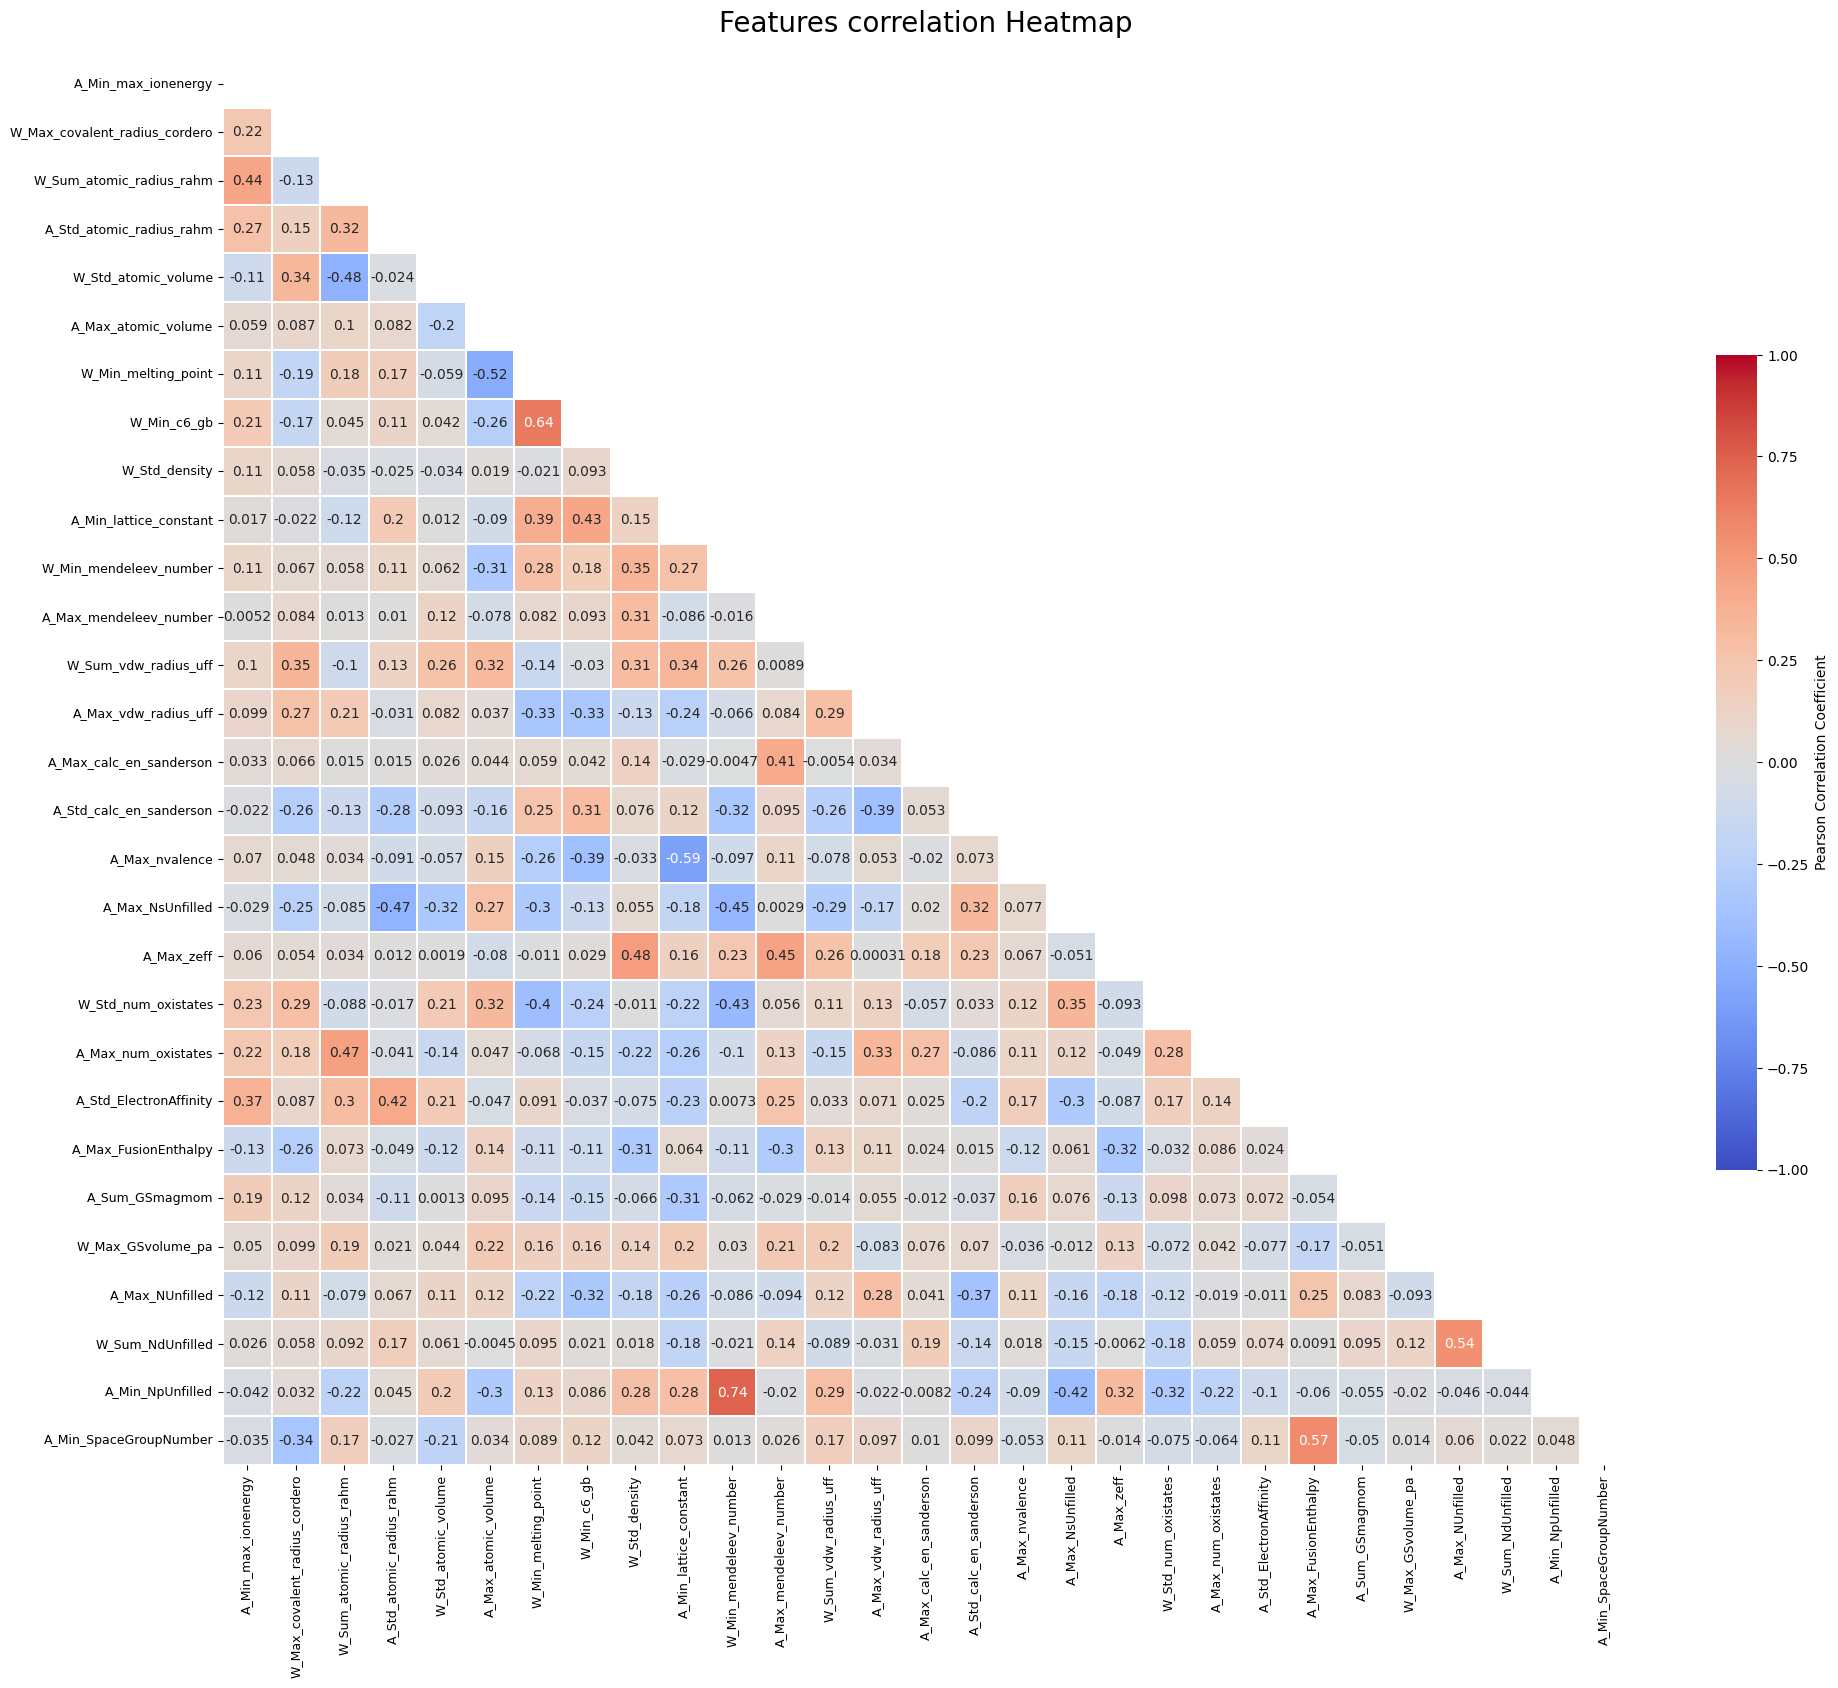

In [128]:
# Selected features visualization
corr_plot = plot_pearson_correlation(X_train_final_standard, show_numbers=True)
corr_plot.savefig(plots_path / 'correlation_matrix.pdf', bbox_inches='tight')

df_features = generate_feature_metadata_table(X_train_final_standard)
display(df_features[['Type', 'Aggregator', 'Chemical Property']])


In [129]:
# Compute Standard VIF
logger.info("Computing Standard OLS VIF on clustered features...")
X_standard_vif_df = calculate_vif(X_train_final_standard)
print("\n--- Standard OLS VIF (Top 10 Worst Features) ---")
print(X_standard_vif_df.head(10))


# Compute Ridge VIF (alpha = 0.1) to see stabilization (Sharma et al. paper)
# logger.info("Computing Ridge VIF (alpha=0,1)...")
# ridge_vif_df = calculate_ridge_vif(X_scaled, alpha=0.1)
# print("\n--- Ridge VIF alpha=0.1 (Top 10 Worst Features) ---")
# print(ridge_vif_df.head(10))

[INFO] 2026-06-07 15:51:58 - Computing Standard OLS VIF on clustered features...
[INFO] 2026-06-07 15:51:58 - Calculating standard OLS VIF for features...

--- Standard OLS VIF (Top 10 Worst Features) ---
                    Feature       VIF
0  W_Sum_atomic_radius_rahm  4.625517
1    W_Min_mendeleev_number  4.335740
2      W_Sum_vdw_radius_uff  4.194785
3       W_Min_melting_point  3.913749
4    A_Min_lattice_constant  3.887445
5          A_Min_NpUnfilled  3.666377
6   A_Std_calc_en_sanderson  3.487820
7          A_Max_NsUnfilled  3.462009
8      A_Max_FusionEnthalpy  3.267071
9       A_Max_atomic_volume  3.193007


[INFO] 2026-06-07 15:51:58 - Computing R and R^2 metrics for 3 targets.
[INFO] 2026-06-07 15:51:59 - Performance metrics computation complete.
[INFO] 2026-06-07 15:51:59 - Rendering performance plots (R, R^2) for Tg_fitted.
[INFO] 2026-06-07 15:52:00 - Rendering performance plots (R, R^2) for m_fitted.
[INFO] 2026-06-07 15:52:00 - Rendering performance plots (R, R^2) for log_eta_inf_fitted.


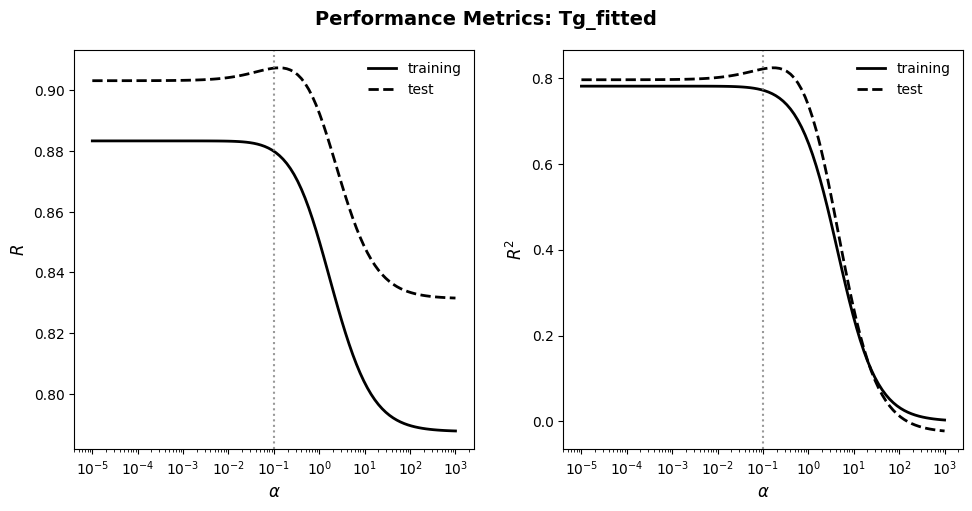

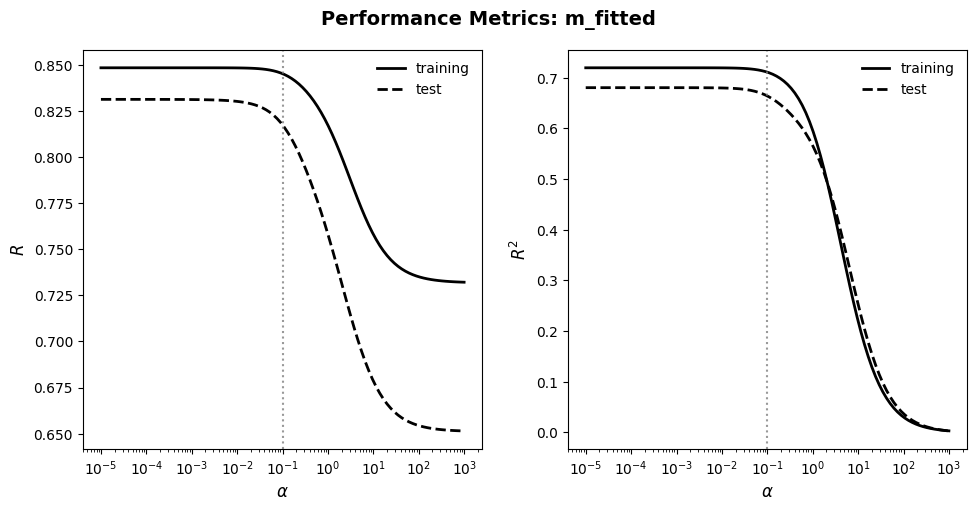

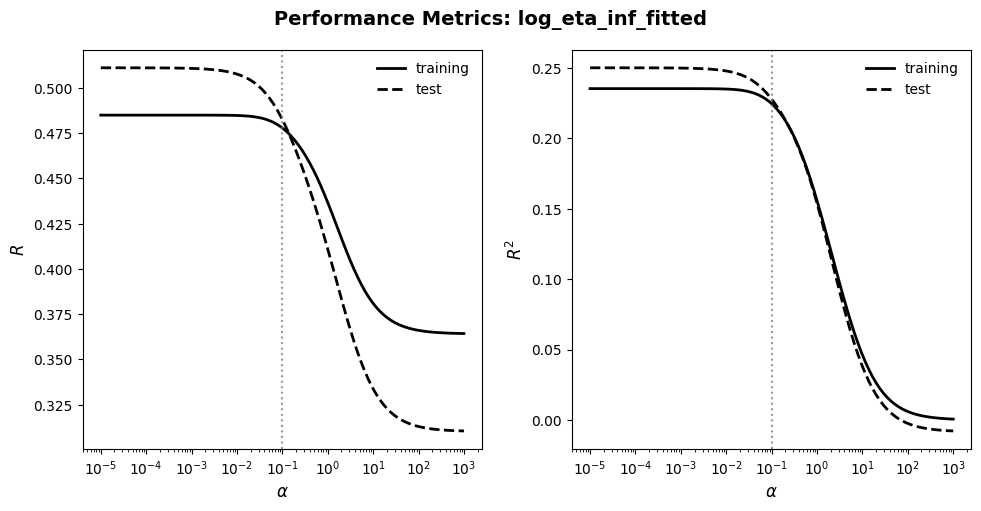

In [130]:
# Model performance analysis as a function of alpha
alphas_spectrum = np.logspace(-5, 3, 100)

performance_results = compute_alpha_performance_metrics(
    X_train_final_standard, 
    y_train_scaled, 
    X_test_final_standard, 
    y_test_scaled, 
    alphas_spectrum
)

performance_plots_path = plots_path / "performance_plots"
performance_plots_path.mkdir(parents=True, exist_ok=True)

for target in performance_results.keys():
    fig = plot_target_performance(
        performance_results[target],
        target_name=target,
        ref_alpha=0.1
    )
    fig.savefig(performance_plots_path / f"{target}.pdf", bbox_inches='tight')

[INFO] 2026-06-07 15:52:03 - Computing robust weight traces across 40 alphas.
[INFO] 2026-06-07 15:52:03 - Averaging over 20 random splits (test_size=0.5).
[INFO] 2026-06-07 15:52:03 - Robust traces computation completed. Packaging results.
[INFO] 2026-06-07 15:52:03 - Rendering robust normalized traces for target: Tg_fitted
[INFO] 2026-06-07 15:52:04 - Rendering robust normalized traces for target: m_fitted
[INFO] 2026-06-07 15:52:04 - Rendering robust normalized traces for target: log_eta_inf_fitted


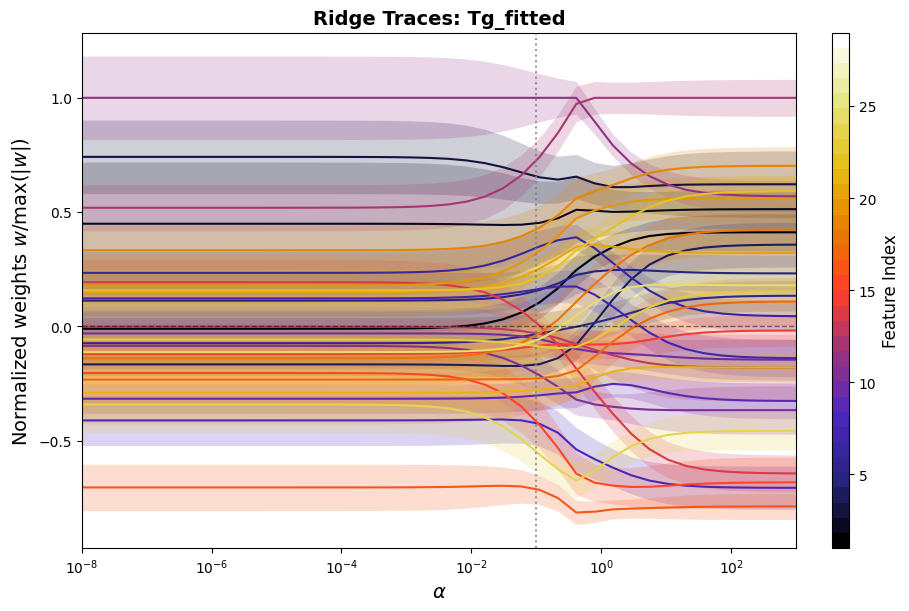

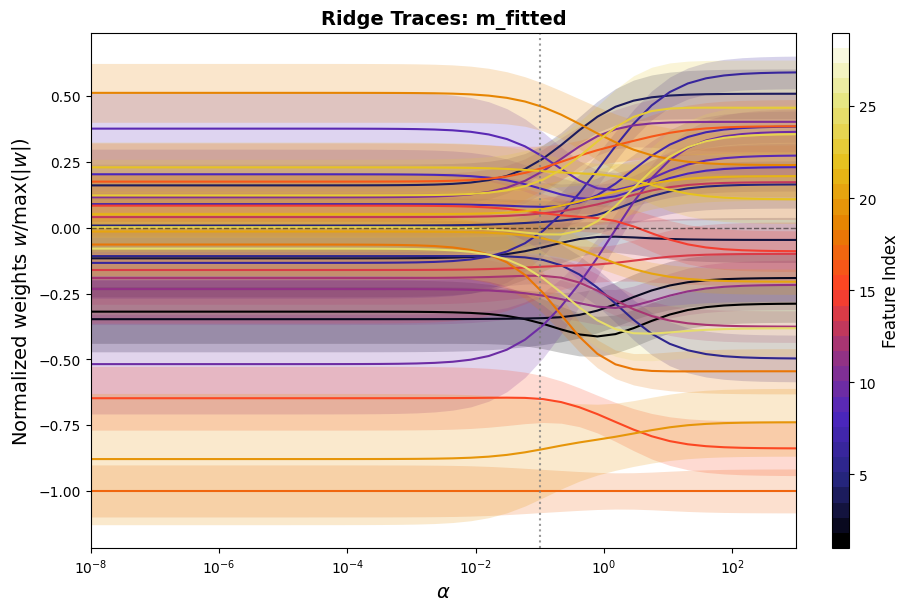

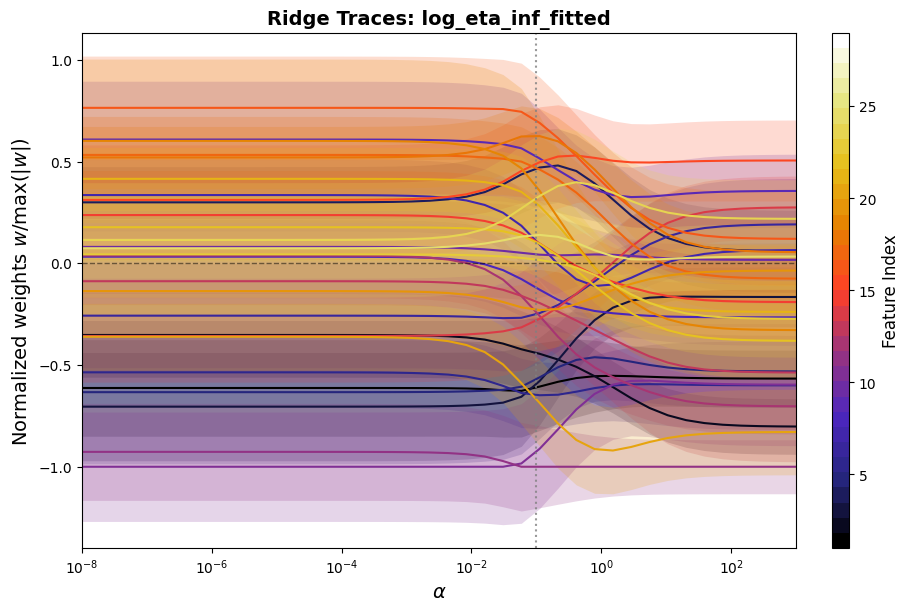

In [131]:
# Features weights analysis in relation to alpha
traces_alphas_spectrum = np.logspace(-8, 3, 40)

robust_traces = compute_weight_traces(
    X=X_train_final_standard,
    y=y_train_scaled,
    alphas=traces_alphas_spectrum,
    n_splits=20,
    test_size=0.5
)

target_names = list(robust_traces.keys())

traces_plots_path = plots_path / "traces_plots"
traces_plots_path.mkdir(parents=True, exist_ok=True)

for target in target_names:
    mean_df = robust_traces[target]["mean_weights"]
    std_df = robust_traces[target]["std_weights"]

    fig = plot_normalized_traces(
        mean_weights=mean_df,
        std_weights=std_df,
        target_name=target
    )
    fig.savefig(traces_plots_path / f"{target}.pdf", bbox_inches='tight')

[INFO] 2026-06-07 15:52:06 - Extracting raw feature importance at alpha=0.1 over 100 splits.
[INFO] 2026-06-07 15:52:03 - Rendering sorted raw feature importance S-curves for 3 targets.


,feature,original_index,weight,std,abs_weight
0,W_Sum_vdw_radius_uff,12,0.327822,0.041357,0.327822
1,A_Max_vdw_radius_uff,13,0.247273,0.030763,0.247273
2,A_Max_zeff,18,-0.234527,0.023136,0.234527
3,W_Sum_atomic_radius_rahm,2,0.220788,0.032236,0.220788
4,A_Min_NpUnfilled,27,-0.188085,0.030942,0.188085
5,W_Max_covalent_radius_cordero,1,0.158966,0.068204,0.158966
6,A_Std_ElectronAffinity,21,0.147010,0.029289,0.147010
7,A_Max_NsUnfilled,17,-0.144849,0.032823,0.144849
8,W_Std_density,8,-0.128305,0.034855,0.128305
9,W_Min_melting_point,6,0.115345,0.026438,0.115345


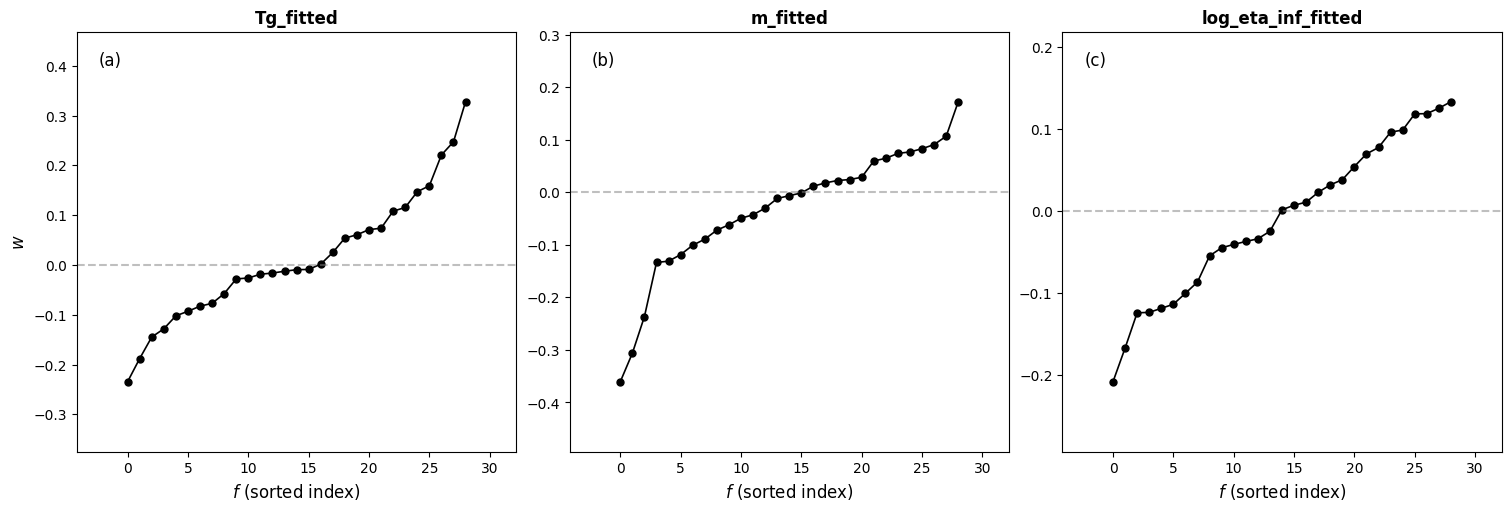

In [132]:
# Feature weights plots (ordered)
importance_data = extract_importance(
    X=X_train_final_standard,
    y=y_train_scaled,
    alpha=0.1,
    n_splits=100,
    sort_by='magnitude' # <- Ordina per il peso più forte, a prescindere dal segno
)

fig_importance = plot_sorted_feature_importance(importance_data, top_n=0)
fig_importance.savefig(plots_path / 'features_importance_ridge.pdf', bbox_inches='tight')


importance_data['Tg_fitted'].head(10)
# print("\nTop 10 features per Tg_fitted:")
# print(importance_data['Tg_fitted'].head(10)[['original_index', 'feature', 'weight', 'abs_weight']])

[INFO] 2026-06-07 15:52:04 - Tracking evolution of top 5 features (identified at alpha=0.1).
[INFO] 2026-06-07 15:52:04 - Rendering evolution plots, highlighting 3 alphas.


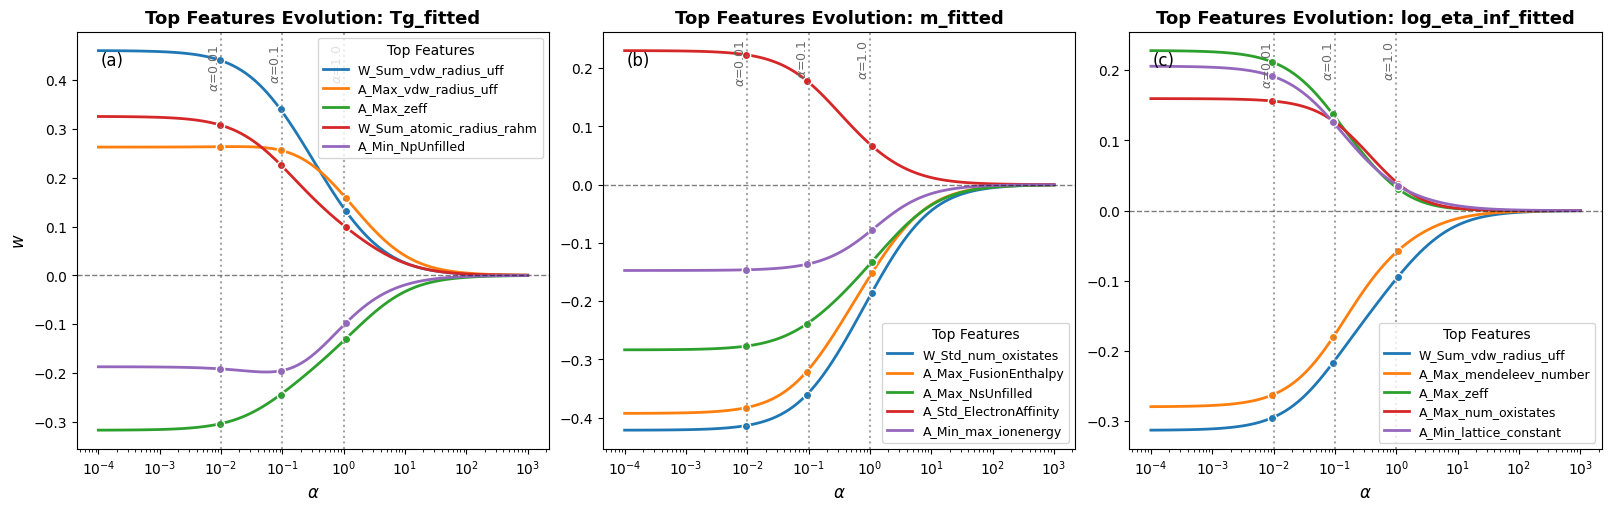

In [133]:
# Top features analisys

alphas_spectrum = np.logspace(-4, 3, 100)

evolution_data = extract_top_features_evolution(
    X=X_train_final_standard,
    y=y_train_scaled,
    alphas=alphas_spectrum,
    ref_alpha=0.1,
    top_n=5
)

selected_alphas = [0.01, 0.1, 1.0]

fig_evolution = plot_top_features_evolution(
    evolution_dict=evolution_data,
    highlight_alphas=selected_alphas
)

fig_evolution.savefig(plots_path / 'top_features_evolution.pdf', bbox_inches='tight')

In [134]:
# Training model

# Instantiate the model with alpha = 0.1
ridge_model = CustomRidgeRegression(alpha=0.1, fit_intercept=True)

# Fit the model on the training data
ridge_model.fit(X_train_final_standard, y_train_scaled)

pickle.dump(ridge_model, open(model_path / "ridge_model.pkl", 'wb'))

logger.info("Model successfully trained and saved!")

[INFO] 2026-06-07 15:52:08 - Model successfully trained and saved!


In [135]:
# Evaluating model

target_columns = ['Tg', 'm','log_eta_inf']

evaluation_metrics = evaluate_final_model(
    model=ridge_model,
    X_test=X_test_final_standard,
    y_test=y_test_scaled,
    viscosity_df=raw_data,
    target_cols=target_columns,
    y_scaler=y_scaler
)

[INFO] 2026-06-07 15:52:08 - Evaluating model on the unseen Test Set (63 glasses)...

      TEST SET PERFORMANCE (SCALED PARAMETERS)
Target: Tg
  Pearson : 0.907
  R^2     : 0.820
  RMSE    : 0.392
  MAE     : 0.285
  MedAE   : 0.199
--------------------------------------------------
Target: m
  Pearson : 0.817
  R^2     : 0.664
  RMSE    : 0.429
  MAE     : 0.367
  MedAE   : 0.331
--------------------------------------------------
Target: log_eta_inf
  Pearson : 0.483
  R^2     : 0.228
  RMSE    : 0.804
  MAE     : 0.551
  MedAE   : 0.425
--------------------------------------------------
[INFO] 2026-06-07 15:52:08 - Computing global viscosity performance via MYEGA equation...

      VISCOSITY: PREDICTED vs TRUE FITTED (MYEGA)
--------------------------------------------------
  Pearson : 0.907
  R^2     : 0.780
  RMSE    : 1.882
  MAE     : 1.173
  MedAE   : 0.649
      VISCOSITY: PREDICTED vs EXPERIMENTAL (GROUND TRUTH)
--------------------------------------------------
  Pearson : 

[INFO] 2026-06-07 15:52:08 - Rendering 2D density correlation plot with residual inset.


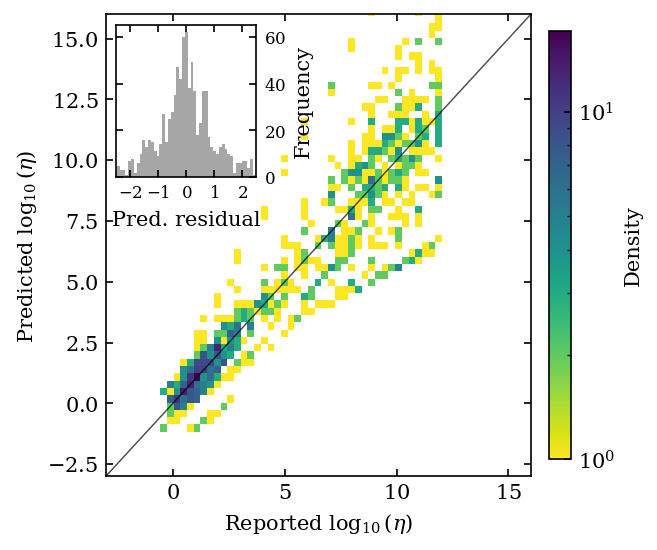

In [136]:
# Cassar density plot

y_true_visc = evaluation_metrics["viscosity_arrays"]["true_experimental"]
y_pred_visc = evaluation_metrics["viscosity_arrays"]["predicted_myega"]

fig_density = plot_viscosity_density_correlation(
    y_true=y_true_visc, 
    y_pred=y_pred_visc
)

fig_density.savefig(plots_path / '2D_density_histogram.pdf', bbox_inches='tight')
fig_density.savefig(plots_path / '2D_density_histogram.png', bbox_inches='tight')

[INFO] 2026-06-07 15:52:10 - Extracting distance and RMSE metrics into a DataFrame.


,ID,Name,Distance,RMSE
0,269,20Al₂O₃.60B₂O₃.20CaO,0.100251,6.808844
1,96,4Al₂O₃.6B₂O₃.56PbO.34SiO₂,0.809830,6.032308
2,22,36Li₂O.64SiO₂,0.021836,3.891660
3,591,11Al₂O₃.24CaO.5Fe₂O₃.2FeO.11MgO.48SiO₂,0.758456,3.563777
4,215,18BaO.22Na₂O.60SiO₂,0.100251,3.057203
5,156,3B₂O₃.10BaO.6K₂O.2Na₂O.1PbO.65SiO₂.12ZnO,0.305371,2.991695
6,799,99GeO₂.1Na₂O,0.687285,2.875088
7,706,20K₂O.50SiO₂.30ZnO,0.338808,2.726946
8,718,22B₂O₃.5FeO.11Na₂O.63SiO₂,0.191207,2.510950
9,798,50GeO₂.50PbO,0.100251,2.488018


[INFO] 2026-06-07 15:52:10 - Rendering square scatter plot for Extrapolation Distance vs RMSE.


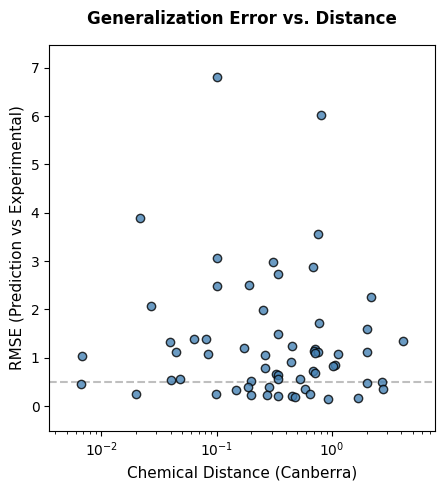

In [137]:
# Test glasses vs performance analysis

# Get glass names
compounds = raw_data.columns[:-3].tolist()
glass_names_dict = generate_glass_names(raw_data, compounds)

# Get model prediction
y_pred_scaled  = ridge_model.predict(X_test_final_standard)
y_pred_physical = y_scaler.inverse_transform(y_pred_scaled)

target_columns = ['Tg', 'm','log_inf']

# Prediction dataframe
predictions_df = pd.DataFrame(
    y_pred_physical,
    columns=target_columns,
    index=y_test.index
)

# Generating distance data
metrics_df = generate_extrapolation_metrics(
    compounds=compounds,
    viscosity_df=raw_data,
    predictions_df=predictions_df, 
    names_dict=glass_names_dict
)
display(metrics_df.head(10))

# Generating distance plot
fig_distance = plot_rmse_vs_distance_square(metrics_df)
fig_distance.savefig(plots_path / 'distance_plot.pdf', bbox_inches='tight')

[INFO] 2026-06-07 15:52:11 - Training ensemble of 100 bootstrap models...
[INFO] 2026-06-07 15:52:11 - Rendering bootstrap prediction grids for 63 glasses.


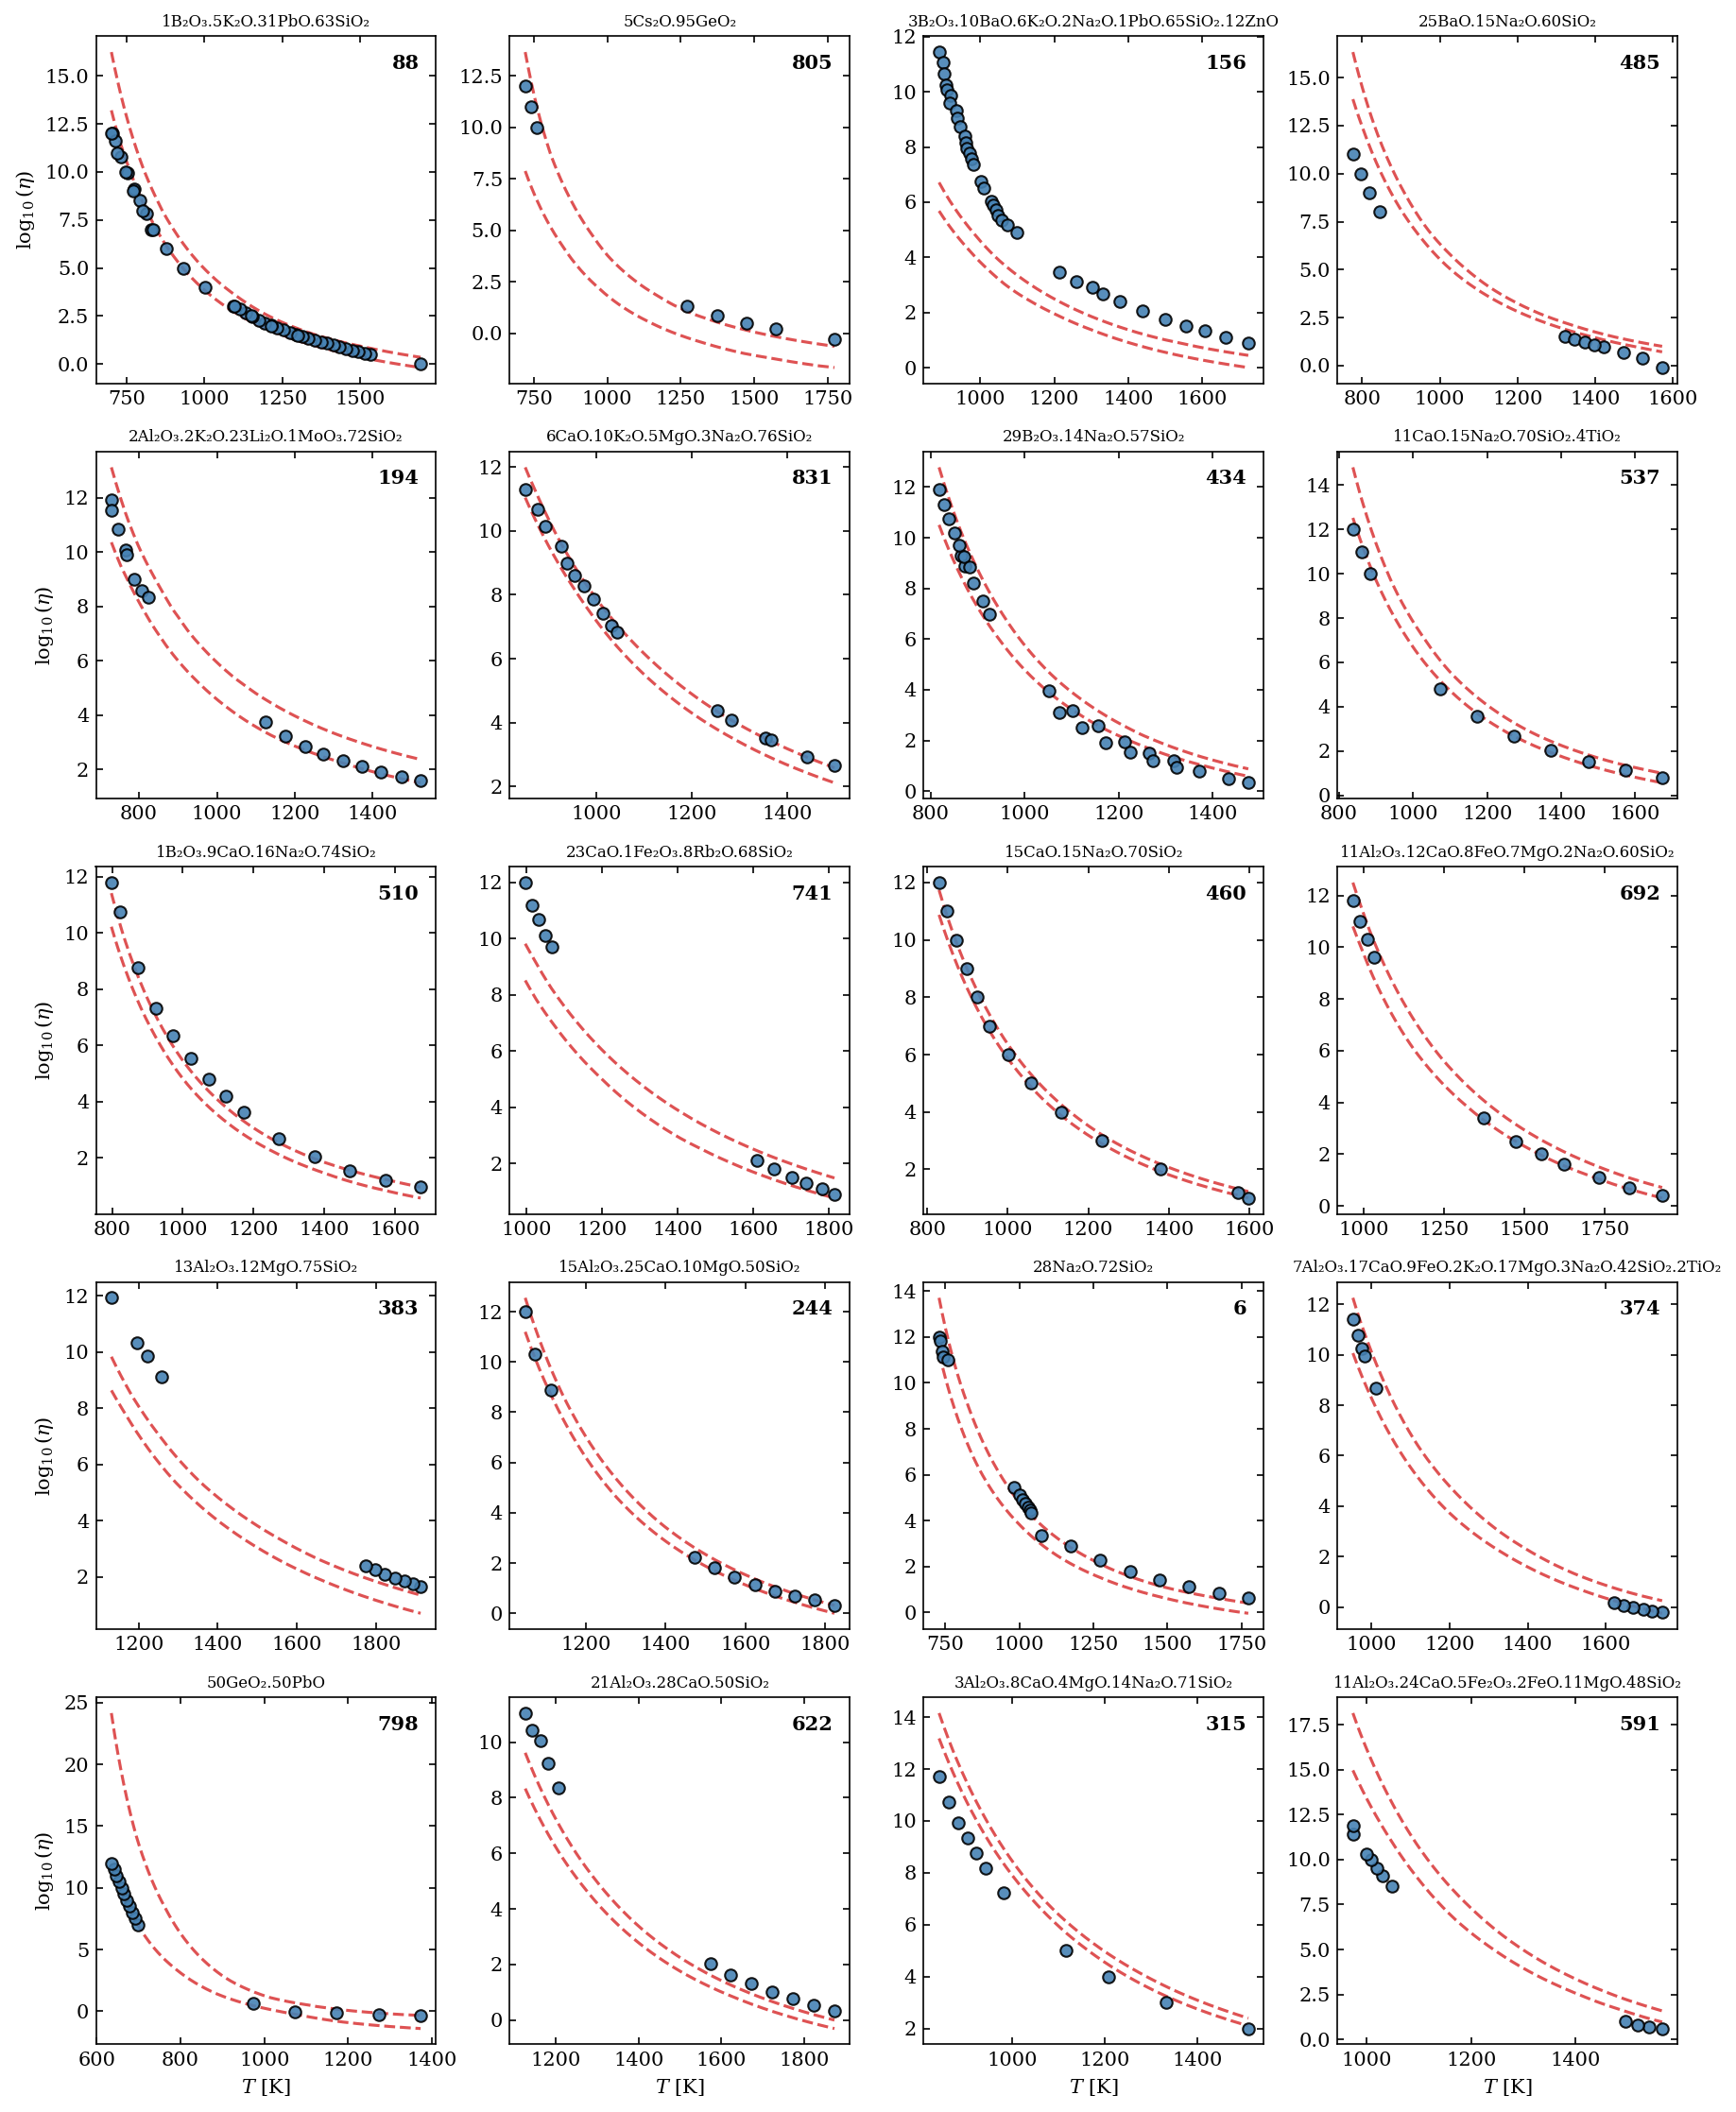

In [138]:
# Plotting test liquids viscosities with uncertainty bars

base_ridge = CustomRidgeRegression(alpha=0.1, fit_intercept=True)

predictions_df, distributions_dict = generate_bootstrap_predictions(
    base_model=base_ridge,
    X_train=X_train_final_standard,
    y_train=y_train_scaled,
    X_test=X_test_final_standard,
    y_scaler=y_scaler,
    n_estimators=100
)

viscosity_plots_path = plots_path / "test_viscosity_plots"
viscosity_plots_path.mkdir(parents=True, exist_ok=True)

plot_viscosity_grids_bootstrap(
    viscosity_df=raw_data,
    distributions_dict=distributions_dict,
    names_dict=glass_names_dict,
    save_dir=viscosity_plots_path,
    confidence=95.0
)